# 01 — Análise Exploratória do Dataset (EDA)

A **Análise Exploratória de Dados** (EDA, do inglês *Exploratory Data Analysis*) é a etapa inicial de qualquer projeto de Machine Learning. Antes de treinar qualquer modelo, é essencial entender profundamente os dados com os quais estamos trabalhando.

Neste notebook, iremos:
- Verificar a estrutura e a qualidade do dataset
- Analisar a distribuição das classes (balanceamento)
- Investigar o tamanho e características dos textos
- Identificar possíveis problemas (dados faltantes, ruídos, etc.)

Essas informações vão guiar todas as decisões técnicas das próximas etapas.

---
**Dataset:** `Boamente_Atualizado_Janeiro_2026.csv`  
**Colunas:** `text` (texto do post) | `label` (0 = sem ideação suicida · 1 = com ideação suicida)

## 1. Importações e Configurações

Aqui carregamos as bibliotecas necessárias para análise e visualização:
- **pandas**: manipulação de dados tabulares
- **matplotlib / seaborn**: criação de gráficos e visualizações estatísticas

O comando `%matplotlib inline` é uma **magic command** do Jupyter que instrui o notebook a renderizar os gráficos diretamente na célula de saída, em vez de abrir uma janela separada.

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

COLUNA_TEXTO = 'text'
COLUNA_LABEL = 'label'

## 2. Carregamento do Dataset

Carregamos o arquivo CSV e fazemos uma primeira inspeção visual. O método `head()` exibe as primeiras linhas, permitindo verificar se os dados foram carregados corretamente e ter uma noção inicial do conteúdo.

In [2]:
df = pd.read_csv('../data/raw/Boamente_Atualizado_Janeiro_2026.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (3777, 2)


,text,label
0,Aquela vontade de acabar com a minha vida voltou,1
1,to triste e com vontade de acabar com a minha ...,1
2,Corinthians ta querendo acabar com minha vida ...,0
3,Alguém poderia por favor me dar um tiro a acab...,1
4,TAYLOR TU VAI acabar com a minha vida MULHER,0
5,Eu vou assistir o jogo todo puto mais uma vez....,0
6,Alguem pode me.indicar uma série uma boa q vai...,0
7,tenho 76 slides p estudar obg faculdade por ac...,0
8,eu nao concordei com um tweet da fernanda agor...,0
9,sessão de foto pra acabar com a minha vida ess...,0


## 3. Estrutura e Qualidade dos Dados

A função `info()` retorna informações essenciais sobre o DataFrame:
- **Dtypes**: tipo de cada coluna (object = texto, int64 = inteiro, etc.)
- **Non-Null Count**: quantidade de valores não nulos — valores nulos precisam ser tratados antes do treinamento
- **Memory usage**: consumo de memória do dataset

Em seguida, verificamos explicitamente se há **dados faltantes** em cada coluna. Textos ou rótulos ausentes precisariam ser removidos ou preenchidos.

In [3]:
df.info()
print('\nValores nulos por coluna:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    3777 non-null   str  
 1   label   3777 non-null   int64
dtypes: int64(1), str(1)
memory usage: 59.1 KB

Valores nulos por coluna:
text     0
label    0
dtype: int64


## 4. Distribuição das Classes

Esta é uma das análises mais importantes do projeto. O **balanceamento das classes** impacta diretamente o desempenho dos classificadores.

- Se as classes forem **balanceadas** (proporção próxima de 50/50), os modelos tendem a aprender bem ambas as categorias.
- Se houver **desbalanceamento** (ex: 90% classe 0 / 10% classe 1), o modelo pode simplesmente "ignorar" a classe minoritária e ainda assim ter alta acurácia — o que seria enganoso. Nesse caso, seria necessário usar técnicas como:
  - `class_weight='balanced'` nos classificadores
  - **SMOTE** (Synthetic Minority Over-sampling Technique)
  - Subamostragem da classe majoritária

O gráfico abaixo mostra a contagem de cada classe.

label
0    2687
1    1090
Name: count, dtype: int64

Proporção:
label
0    71.14
1    28.86
Name: proportion, dtype: float64%


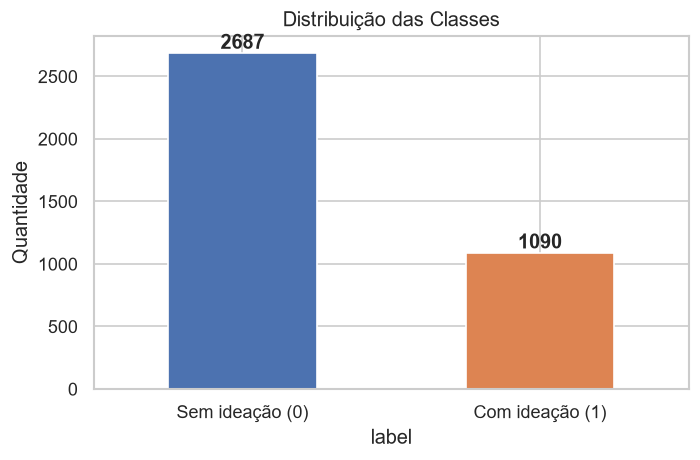

In [4]:
contagem = df[COLUNA_LABEL].value_counts()
print(contagem)
print(f'\nProporção:\n{df[COLUNA_LABEL].value_counts(normalize=True).mul(100).round(2)}%')

fig, ax = plt.subplots(figsize=(6, 4))
contagem.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_xticklabels(['Sem ideação (0)', 'Com ideação (1)'], rotation=0)
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição das Classes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análise do Tamanho dos Textos

Entender o tamanho dos textos é fundamental para:
- Escolher o método de vetorização mais adequado
- Identificar outliers (textos muito curtos ou muito longos)
- Definir parâmetros como o vocabulário máximo do TF-IDF

Criamos duas métricas:
- **`n_palavras`**: número de tokens (palavras) por texto
- **`n_chars`**: número de caracteres por texto

O `describe()` exibe estatísticas descritivas: mínimo, máximo, média, mediana (50%) e desvio padrão.

In [5]:
df['n_palavras'] = df[COLUNA_TEXTO].str.split().str.len()
df['n_chars']    = df[COLUNA_TEXTO].str.len()

print('=== Estatísticas: Número de palavras ===')
print(df['n_palavras'].describe().round(2))
print('\n=== Estatísticas: Número de caracteres ===')
print(df['n_chars'].describe().round(2))

=== Estatísticas: Número de palavras ===
count    3777.00
mean       15.00
std        11.44
min         1.00
25%         7.00
50%        12.00
75%        19.00
max        62.00
Name: n_palavras, dtype: float64

=== Estatísticas: Número de caracteres ===
count    3777.00
mean       77.27
std        60.81
min         9.00
25%        35.00
50%        59.00
75%        97.00
max       297.00
Name: n_chars, dtype: float64


### 5.1 Visualização do Tamanho por Classe

O **boxplot** compara a distribuição do tamanho dos textos entre as classes. Se textos de uma classe forem sistematicamente mais longos, isso pode ser uma feature relevante por si só.

O **histograma** mostra a distribuição geral do número de palavras, revelando se a maioria dos textos é curta (comum em redes sociais como Twitter/X) ou mais longa.

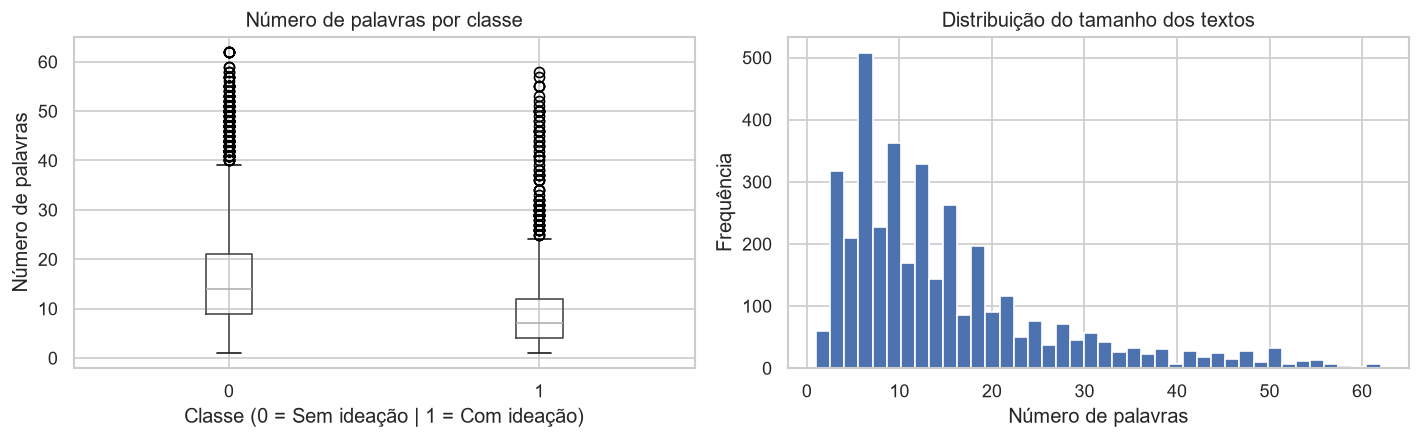

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot: tamanho por classe
df.boxplot(column='n_palavras', by=COLUNA_LABEL, ax=axes[0])
axes[0].set_title('Número de palavras por classe')
axes[0].set_xlabel('Classe (0 = Sem ideação | 1 = Com ideação)')
axes[0].set_ylabel('Número de palavras')
plt.sca(axes[0])  # garante que o título do suptitle não sobreponha

# Histograma: distribuição geral
df['n_palavras'].hist(bins=40, ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribuição do tamanho dos textos')
axes[1].set_xlabel('Número de palavras')
axes[1].set_ylabel('Frequência')

plt.suptitle('')   # remove título automático do pandas
plt.tight_layout()
plt.show()

## 6. Exemplos por Classe

Ler exemplos reais de cada classe é fundamental para desenvolver intuição sobre o problema. Isso ajuda a identificar:
- Padrões de linguagem associados à ideação suicida
- Textos ambíguos ou irônicos que podem confundir os classificadores (ex: uso metafórico de expressões como "quero morrer")
- A qualidade geral dos rótulos do dataset

In [7]:
print('=== Exemplos COM ideação suicida (label = 1) ===')
for txt in df[df[COLUNA_LABEL] == 1][COLUNA_TEXTO].sample(5, random_state=42):
    print(f'  • {txt}')

print('\n=== Exemplos SEM ideação suicida (label = 0) ===')
for txt in df[df[COLUNA_LABEL] == 0][COLUNA_TEXTO].sample(5, random_state=42):
    print(f'  • {txt}')

=== Exemplos COM ideação suicida (label = 1) ===
  • pra q estudar se eu vou me matar msm?
  • hj to suave só pensei em me matar 228 vezes
  • mas atualizando num geral minha vida: tudo ta uma merda olha que delicia a depressao me pegou de um jeito me fodeu todinha awwn owwn minha crises tao pior e a vontade de me matar eh diaria e toda hora. to me sentindo vazia sozinha um lixo e tô achando que eu tenho alguma outra
  • mds não tem jeito vou ter que me matar
  • ja posso me matar?

=== Exemplos SEM ideação suicida (label = 0) ===
  •  não defendo eles não.

É que numa balança de ruindade, a gente pende pra um lado.
E se for pra assistir coisa ruim, pelo menos assisto esquadrão suicida
  • Hoje eu fiquei por aqui mais que o normal, bora estudar é kié. Beijos pra minha tl que hj só faltou me matar de tanto que me fez rir.
  • tão dizendo que vazou GOT eu já recebi um suposto spoiler mds eu quero morrer tyrion naaaaaaao pic.twitter.comdCLVPvPMls
  • Eu fico imaginando eu num ligar que te